<a href="https://colab.research.google.com/github/kmardamb/DATA-205-Spring-2026/blob/main/DATA201_Week3_Assignment_KarimM(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 – Week 3 Assignment

## Visualization + Linear Regression (R → Python Bridge)

**Submission:** Jupyter Notebook (.ipynb) in Github + attach to Team  
**Dataset:** housing.csv  
**Focus:** Interpretation \> Syntax

------------------------------------------------------------------------

# Part I – Visualization (40 pts)

## A. Scatterplots and Aesthetics

1.  Create a scatterplot of **size vs price**.

    -   Label axes clearly.
    -   Add a meaningful title.

2.  Recreate the plot using `color = neighborhood` (use seaborn).

3.  Use transparency (`alpha`) to reduce overplotting.

### Short Answer (3–4 sentences)

-   What does seaborn automatically handle that matplotlib does not?
-   Why is transparency useful here?

------------------------------------------------------------------------

## B. Small Multiples (Faceting)

Create small multiples of **size vs price**, separated by `bedrooms`.

-   Keep scales consistent.
-   Add a clear overall title.

### Question

Does the relationship between size and price look similar across bedroom
counts?

------------------------------------------------------------------------

## C. Distribution and Categorical Plots

1.  Create a histogram of `price`.
2.  Create a density plot of `price`.
3.  Create a boxplot of `price` by `neighborhood`.

### Interpretation (short paragraph)

-   Do neighborhoods differ systematically in price?
-   What visual evidence supports your claim?

------------------------------------------------------------------------

# Part II – Linear Regression for Inference (30 pts)

## A. Multiple Regression (R → Python)

In R, the model would be:

``` r
lm(price ~ size + bedrooms + neighborhood, data = df)
```

In Python:

1.  Fit the equivalent model using `statsmodels`.
2.  Report:
    -   Coefficient estimates
    -   Standard errors
    -   R²

------------------------------------------------------------------------

## B. Interpretation

Answer clearly:

1.  Interpret the coefficient on **size**, explicitly stating what is
    being held constant.
2.  Is size statistically significant? How do you know?
3.  What does R² tell us in this context?

------------------------------------------------------------------------

# Part III – Prediction Workflow (20 pts)

Now switch goals: **Prediction instead of explanation**

1.  Split the data into training and test sets.
2.  Fit linear regression using `scikit-learn`.
3.  Compute:
    -   RMSE (on test set)
    -   R² (on test set)

------------------------------------------------------------------------

## Short Answer

-   Why does scikit-learn not report p-values?
-   Which workflow would you use for:
    -   Explanation?
    -   Prediction?
-   Why are these different goals?

------------------------------------------------------------------------

# Part IV – Integrated Thinking (10 pts)

Create one polished figure that:

-   Shows size vs price
-   Colors by neighborhood
-   Includes a regression line
-   Has professional formatting

Then write 4–5 sentences:

-   Does the regression model match what you visually observed?
-   Did the visualization help you anticipate the model results?

------------------------------------------------------------------------

# Grading Rubric

| Component                    | Points  |
|:-----------------------------|:--------|
| Visualization accuracy       | 20      |
| Visualization interpretation | 20      |
| Regression implementation    | 20      |
| Regression interpretation    | 10      |
| Prediction workflow          | 20      |
| Integrated reasoning         | 10      |
| **Total**                    | **100** |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


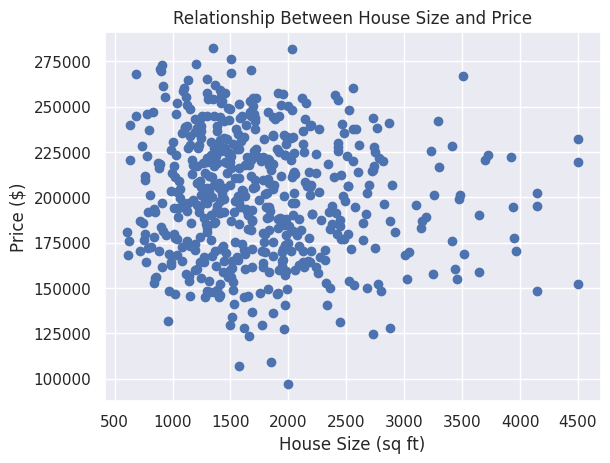

In [5]:
plt.scatter(df["size"], df["price"])
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price ($)")
plt.title("Relationship Between House Size and Price")
plt.show()

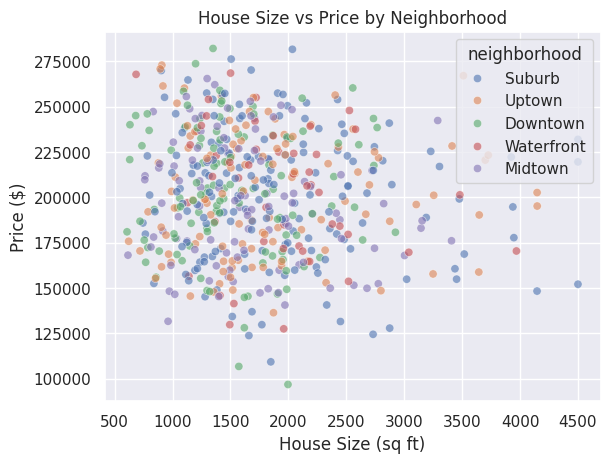

In [6]:
sns.scatterplot(data=df, x="size", y="price", hue="neighborhood", alpha=0.6)
plt.title("House Size vs Price by Neighborhood")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price ($)")
plt.show()

Seaborn automatically convert data and create statistical visualizations. It can automatically group data and categories, and created the necessary visuals without any extra code needed.

Transperancy (also known as alpha) gives the visual a better read of the density of the data and is readible to the consumer by not having points overlap.

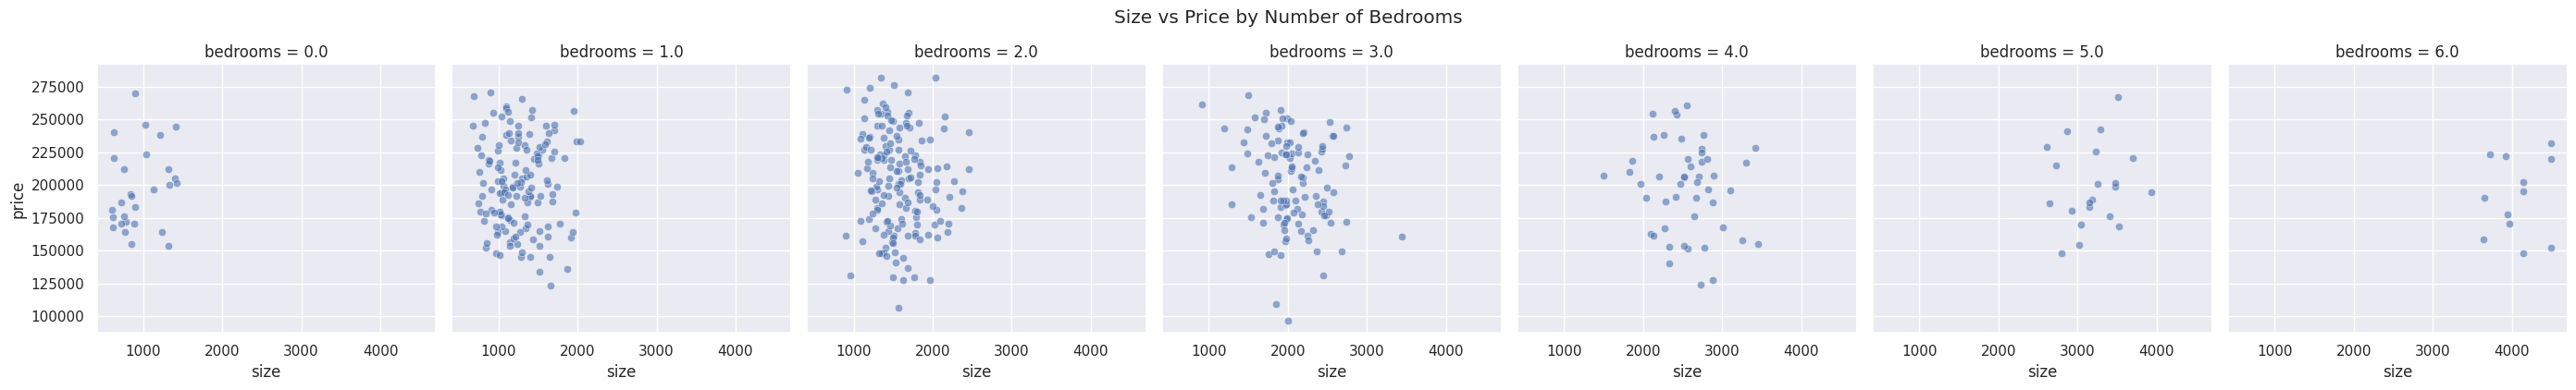

In [7]:
g = sns.FacetGrid(df, col="bedrooms", height=4, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="size", y="price", alpha=0.6)
g.fig.suptitle("Size vs Price by Number of Bedrooms", y=1.05)
plt.show()

The correlation between price and size in square feet is generally positive. As the size of the house and bedrooms increases, the price increases with it.

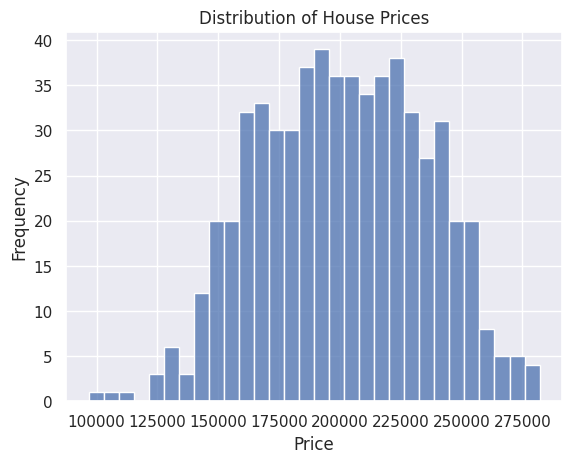

In [8]:
sns.histplot(df["price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

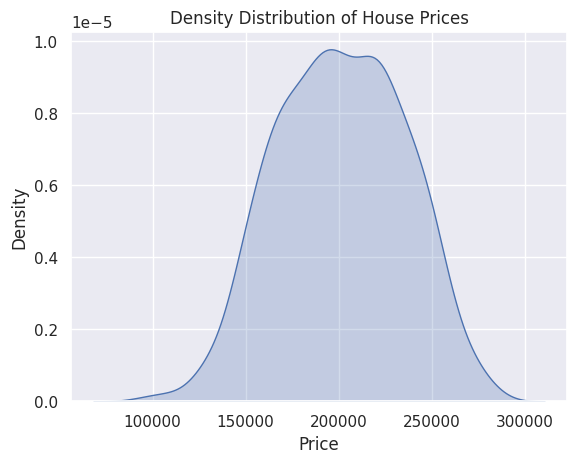

In [9]:
sns.kdeplot(df["price"], fill=True)
plt.title("Density Distribution of House Prices")
plt.xlabel("Price")
plt.show()

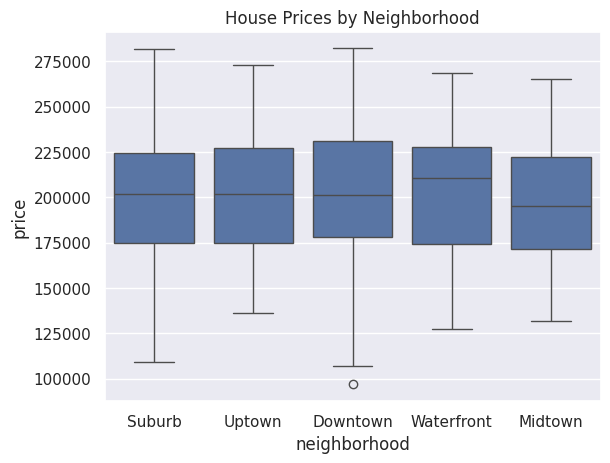

In [10]:
sns.boxplot(data=df, x="neighborhood", y="price")
plt.title("House Prices by Neighborhood")
plt.show()

It seems based on the box plot that neighborhoods play a role in the prices of the houses. The boxplots show the variety of prices and medians based on the locations of said homes.

In [11]:
import statsmodels.formula.api as smf

model = smf.ols("price ~ size + bedrooms + C(neighborhood)", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.190
Time:                        03:18:59   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

1. If the coefficient of the linear regression model is positive in this case, then it means that larges houses correlates with higher prices.

2. The p-value is below 0.05, indicating a strong relationship between the size of the house and the price.

3. R^2 tells us that the variation of housing prices is dependent on; house size, bedrooms and locations.

In [25]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df[["size","bedrooms","neighborhood"]], drop_first=True)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
df2 = df[["size", "bedrooms", "neighborhood", "price"]].copy()

df2 = df2.dropna()

X = pd.get_dummies(df2[["size", "bedrooms", "neighborhood"]], drop_first=True)
y = df2["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 33590.168864545485
R2: -0.0393556570351552


It focuses on predictive behavior and not statistical analysis.

Explanational models usually use statsmodels, while predictive models use scikit-learn, which has the capability to train models.

Explanation prioritizes understanding the relationship in the model, while predictive helps understand future behaviors in data that allow people to make better assesments.

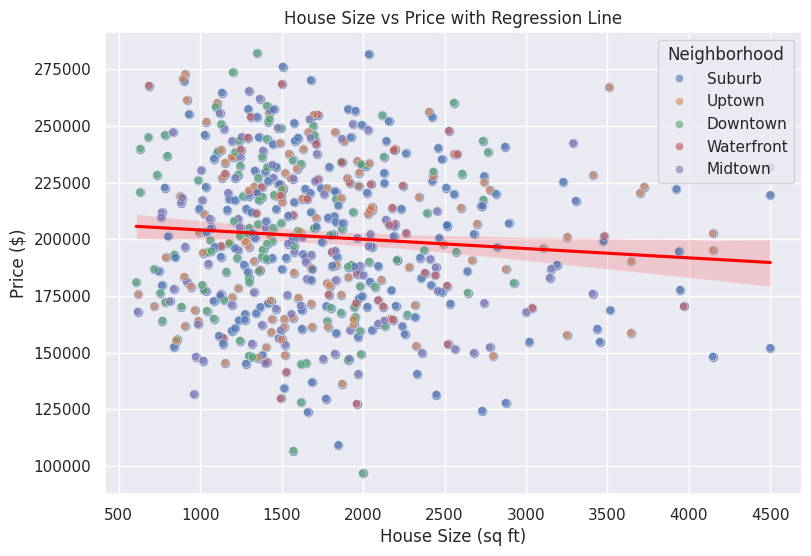

In [24]:
plt.figure(figsize=(9,6))
sns.regplot(
    data=df,
    x="size",
    y="price",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

sns.scatterplot(
    data=df,
    x="size",
    y="price",
    hue="neighborhood",
    alpha=0.6
)

plt.title("House Size vs Price with Regression Line")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price ($)")
plt.legend(title="Neighborhood")
plt.show()

Yes the regression model helped me understand what I was looking at, overall suburban neighborhoods were more expensive. The scatter plot clearly shows the positive relationship between housing size and price, which we saw in the coefficient. The colors are a good representation of the relationship between types of neighborhoods and their values.